In [1]:
library(patchwork)
library(viridis)


#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))

Loading required package: viridisLite

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/13_Axin1_2/code



In [2]:
args = list()
args$sce <- io$rna.sce
args$metadata <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$umap <- file.path(io$basedir,"results/rna/dimensionality_reduction/sce/none/umap_features2500_pcs15_neigh20_dist0.3.txt.gz")
args$outdir <- file.path(io$basedir,"results/rna/plots")
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)


In [3]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE]

In [4]:
table(sample_metadata$sample)


LibA_DKOAxin1Axin2_E6_1_IGO_14590_1            LibB_WT_E6_1_IGO_14590_2 
                               4460                                6421 

In [5]:


###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
 sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# # Add sample metadata as colData
 colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

Loading required package: scuttle



In [6]:
umap = fread(args$umap) %>% 
    .[match(colnames(sce), cell)] %>% 
    .[,genotype:=stringr::str_replace_all(sample_metadata$tdTom, c('FALSE'='WT', 'TRUE'='dKO'))] %>% 
    .[,genotype:=factor(genotype, levels=c('WT', 'dKO'))]

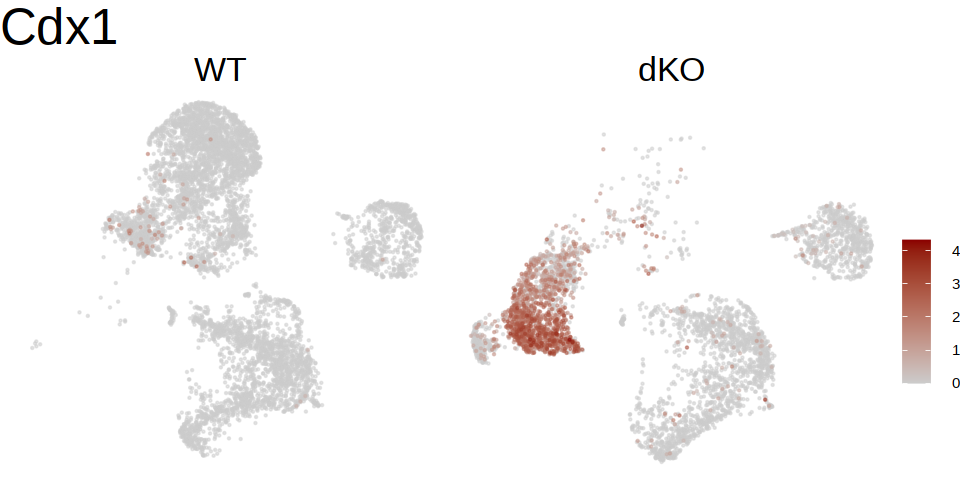

In [7]:
gene = 'Cdx1'

umap = umap[match(colnames(sce), cell)]
umap$gene = as.vector(logcounts(sce[gene,])) 
umap = umap[order(gene)]

options(repr.plot.width=8, repr.plot.height=4)
ggplot(umap, aes(UMAP1, UMAP2, col=gene)) + 
    geom_point(size=0.2, alpha=0.5) +
    scale_color_gradient(low='grey80', high='darkred', name='') + 
    facet_wrap(~genotype) + 
    ggtitle(gene) + 
    theme_void() + 
    theme(strip.text=element_text(size=20),
         title=element_text(size=25))

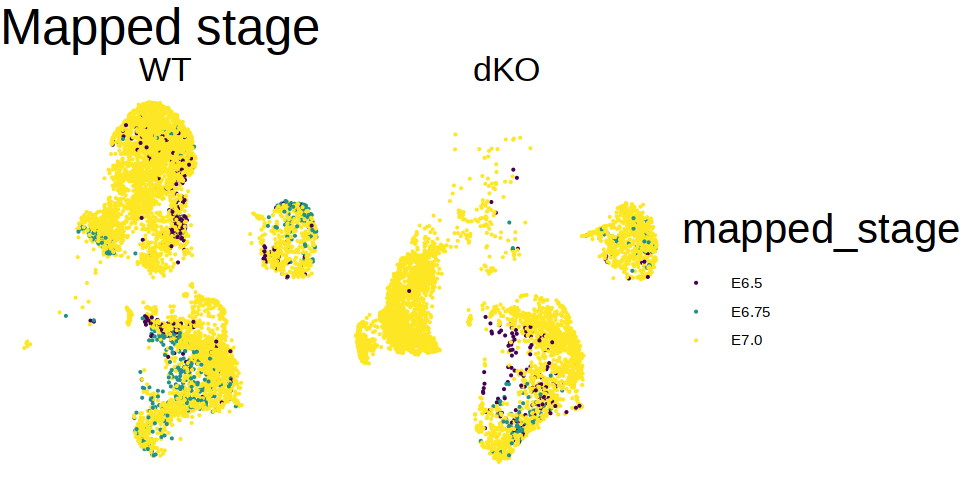

In [22]:
umap = umap[match(colnames(sce), cell)]
umap$mapped_stage = sample_metadata$stage.mapped_mnn
#umap = umap[order(gene)]

opts$stage.colors2 <- viridis::viridis(n=length(unique(umap$mapped_stage)))
names(opts$stage.colors2) <- rev(names(opts$stage.colors2))

options(repr.plot.width=8, repr.plot.height=4)
ggplot(umap, aes(UMAP1, UMAP2, col=mapped_stage)) + 
    geom_point(size=0.1) +
    scale_color_manual(values=opts$stage.colors2) + 
    facet_wrap(~genotype) + 
    ggtitle('Mapped stage') + 
    theme_void() + 
    theme(strip.text=element_text(size=20),
         title=element_text(size=25))

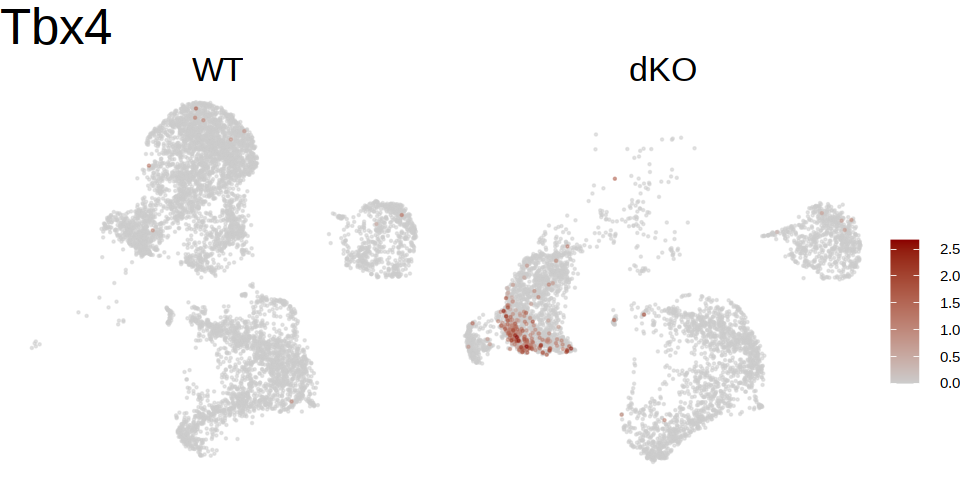

In [9]:
gene = 'Tbx4'

umap = umap[match(colnames(sce), cell)]
umap$gene = as.vector(logcounts(sce[gene,])) 
umap = umap[order(gene)]

options(repr.plot.width=8, repr.plot.height=4)
ggplot(umap, aes(UMAP1, UMAP2, col=gene)) + 
    geom_point(size=0.2, alpha=0.5) +
    scale_color_gradient(low='grey80', high='darkred', name='') + 
    facet_wrap(~genotype) + 
    ggtitle(gene) + 
    theme_void() + 
    theme(strip.text=element_text(size=20),
         title=element_text(size=25))